<a href="https://colab.research.google.com/github/Rashmika2004oshan/Database_Assesment/blob/main/Rstudio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

first change the colab runtime

Then Install Packages

In [ ]:
install.packages("sqldf")

install.packages("readr")

install.packages("dplyr")

install.packages("ggplot2")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘RSQLite’, ‘chron’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



LOAD LIBRARIES

In [ ]:
library(sqldf)

library(readr)

library(dplyr)

library(ggplot2)

Upload csv files and load

In [ ]:
orders <- read_csv("orders.csv")

deliveries <- read_csv("deliveries.csv")

customers <- read_csv("customers.csv")

complaints <- read_csv("complaints.csv")

drivers <- read_csv("drivers.csv")

Rows: 1250 Columns: 11
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (7): order_id, customer_id, service_type, pickup_zone, dropoff_zone, pr...
dbl  (3): promised_window_hours, order_value, special_handling_flag
dttm (1): order_created_at

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 950 Columns: 13
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (6): delivery_id, order_id, driver_id, vehicle_id, hub_id, delivery_status
dbl  (5): route_distance_km, manual_route_override_count, proof_of_completio...
dttm (2): dispatch_time, delivery_completed_at

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 650 Columns: 9
── Column specification ──────────────────────────

Preview dataset

In [ ]:
head(orders)
head(deliveries)

order_id,customer_id,service_type,order_created_at,promised_window_hours,pickup_zone,dropoff_zone,priority_level,order_value,booking_channel,special_handling_flag
<chr>,<chr>,<chr>,<dttm>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<chr>,<dbl>
O00001,C0292,Passenger,2024-08-20 14:43:00,6,Airport,South,Medium,126.65,App,0
O00002,C0459,Passenger,2024-05-14 22:16:00,24,North,AIRPORT,Low,109.30,App,0
O00003,C0161,Passenger,2025-09-02 14:37:00,4,West,AIRPORT,High,33.50,Phone,0
O00004,C0520,Parcel,2025-01-11 17:15:00,2,RiverSide,North,Medium,10.04,App,1
O00005,C0558,Retail,2025-02-17 19:32:00,12,Riverside,SOUTH,Low,125.58,Phone,0
O00006,C0437,Retail,2024-08-05 04:55:00,1,CENTRAL,East,High,151.44,Web,1


delivery_id,order_id,driver_id,vehicle_id,hub_id,dispatch_time,delivery_completed_at,delivery_status,route_distance_km,manual_route_override_count,proof_of_completion_missing,customer_rating_post_delivery,fuel_or_charge_cost
<chr>,<chr>,<chr>,<chr>,<chr>,<dttm>,<dttm>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
DL00001,O00938,D004,V056,H05,2024-06-18 10:57:00,2024-06-19 09:05:59,Failed,17.26,1,0,3.07,12.05
DL00002,O00004,D138,V007,H02,2025-01-11 18:45:00,2025-01-11 17:39:00,OnTime,10.34,1,0,5.00,13.41
DL00003,O00639,D006,V049,H02,2025-06-02 20:39:00,2025-06-02 21:45:32,OnTime,7.92,0,0,4.98,8.51
DL00004,O00313,D116,V055,H02,2024-03-08 23:31:00,2024-03-09 23:30:08,Delayed,16.42,0,0,4.18,13.62
DL00005,O00844,D108,V034,H01,2025-09-21 11:43:00,2025-09-21 15:45:34,OnTime,14.52,1,0,4.18,9.22
DL00006,O00029,D037,V098,H03,2024-09-11 12:40:00,2024-09-12 17:11:52,Delayed,13.84,0,0,1.57,9.58


In [ ]:
head(customers)
head(complaints)

customer_id,age,home_zone,customer_type,signup_date,loyalty_score,app_engagement_score,preferred_channel,account_status
<chr>,<dbl>,<chr>,<chr>,<dttm>,<dbl>,<dbl>,<chr>,<chr>
C0001,26,North,SME,2024-11-27 04:25:00,44.9,69.2,App,Active
C0002,61,AIRPORT,Consumer,2025-10-28 01:04:00,55.4,66.6,App,Active
C0003,66,East,Consumer,2025-07-02 03:23:00,75.9,33.8,NA,Active
C0004,75,CENTRAL,Consumer,2025-08-19 01:58:00,32.5,33.0,App,Active
C0005,26,Riverside,Consumer,2025-06-03 06:02:00,55.9,100.0,Web,Active
C0006,41,WEST,Consumer,2024-03-29 13:26:00,39.9,43.3,Web,Active


complaint_id,customer_id,order_id,complaint_type,channel,severity,created_at,status,resolution_days,compensation_amount
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dttm>,<chr>,<dbl>,<dbl>
CP0001,C0464,O00814,AppIssue,App,High,2025-03-30 02:36:00,Open,11,23.99
CP0002,C0056,O00628,MissedPickup,Phone,Medium,2024-11-07 10:05:00,Open,4,21.64
CP0003,C0469,O00384,Delay,Chatbot,High,2024-01-02 15:47:00,Open,16,26.41
CP0004,C0631,O00406,Delay,App,Medium,2025-01-14 13:07:00,AwaitingCustomer,7,23.44
CP0005,C0535,O00154,Delay,Email,Medium,2024-08-31 05:56:00,Resolved,1,16.18
CP0006,C0096,O00147,Delay,App,Medium,2024-07-22 07:43:00,Resolved,9,18.51


check missing values

In [ ]:
cat("Orders\n")
colSums(is.na(orders))

cat("\nDeliveries\n")
colSums(is.na(deliveries))

cat("\nCustomers\n")
colSums(is.na(customers))

cat("\nComplaints\n")
colSums(is.na(complaints))

cat("\nDrivers\n")
colSums(is.na(drivers))

Orders


order_id           customer_id          service_type 
                    0                     0                     0 
     order_created_at promised_window_hours           pickup_zone 
                    0                     0                     0 
         dropoff_zone        priority_level           order_value 
                    0                     0                     0 
      booking_channel special_handling_flag 
                   25                     0


Deliveries


delivery_id                      order_id 
                            0                             0 
                    driver_id                    vehicle_id 
                            0                             0 
                       hub_id                 dispatch_time 
                            0                             0 
        delivery_completed_at               delivery_status 
                           19                             0 
            route_distance_km   manual_route_override_count 
                            0                             0 
  proof_of_completion_missing customer_rating_post_delivery 
                            0                            14 
          fuel_or_charge_cost 
                            0


Customers


customer_id                  age            home_zone 
                   0                    0                    0 
       customer_type          signup_date        loyalty_score 
                   0                    0                   20 
app_engagement_score    preferred_channel       account_status 
                   0                   13                    0


Complaints


complaint_id         customer_id            order_id      complaint_type 
                  0                   0                   0                   0 
            channel            severity          created_at              status 
                  0                   0                   0                   0 
    resolution_days compensation_amount 
                  0                  16


Drivers


driver_id        base_zone  employment_type years_experience 
               0                0                0                0 
  training_score    driver_rating shift_preference      active_flag 
               7                0                0                0

Clean Data

In [ ]:
orders <- na.omit(orders)

deliveries <- na.omit(deliveries)

customers <- na.omit(customers)

complaints <- na.omit(complaints)

drivers <- na.omit(drivers)

Again check missing values after cleaning

In [ ]:
cat("Orders\n")
colSums(is.na(orders))

cat("\nDeliveries\n")
colSums(is.na(deliveries))

cat("\nCustomers\n")
colSums(is.na(customers))

cat("\nComplaints\n")
colSums(is.na(complaints))

cat("\nDrivers\n")
colSums(is.na(drivers))

Orders


order_id           customer_id          service_type 
                    0                     0                     0 
     order_created_at promised_window_hours           pickup_zone 
                    0                     0                     0 
         dropoff_zone        priority_level           order_value 
                    0                     0                     0 
      booking_channel special_handling_flag 
                    0                     0


Deliveries


delivery_id                      order_id 
                            0                             0 
                    driver_id                    vehicle_id 
                            0                             0 
                       hub_id                 dispatch_time 
                            0                             0 
        delivery_completed_at               delivery_status 
                            0                             0 
            route_distance_km   manual_route_override_count 
                            0                             0 
  proof_of_completion_missing customer_rating_post_delivery 
                            0                             0 
          fuel_or_charge_cost 
                            0


Customers


customer_id                  age            home_zone 
                   0                    0                    0 
       customer_type          signup_date        loyalty_score 
                   0                    0                    0 
app_engagement_score    preferred_channel       account_status 
                   0                    0                    0


Complaints


complaint_id         customer_id            order_id      complaint_type 
                  0                   0                   0                   0 
            channel            severity          created_at              status 
                  0                   0                   0                   0 
    resolution_days compensation_amount 
                  0                   0


Drivers


driver_id        base_zone  employment_type years_experience 
               0                0                0                0 
  training_score    driver_rating shift_preference      active_flag 
               0                0                0                0

Fill numeric values with mean

In [ ]:
deliveries$fuel_or_charge_cost[
is.na(deliveries$fuel_or_charge_cost)
] <- mean(
deliveries$fuel_or_charge_cost,
na.rm = TRUE
)

SQL IN R SECTION

SQL QUERY 1

In [ ]:
sqldf("
SELECT delivery_status,
COUNT(*) AS total
FROM deliveries
GROUP BY delivery_status
")

delivery_status,total
<chr>,<int>
Delayed,193
Failed,128
OnTime,596


SQL QUERY 2 fuel cost query

In [ ]:
sqldf("
SELECT hub_id,
AVG(fuel_or_charge_cost) AS avg_cost
FROM deliveries
GROUP BY hub_id
ORDER BY avg_cost DESC
")

hub_id,avg_cost
<chr>,<dbl>
H05,13.62723
H06,13.40939
H04,13.19675
H07,12.99295
H01,12.75295
H03,12.65763
H02,12.51167
H08,11.73268


SQL QUERY 3 complaints query

In [ ]:
sqldf("
SELECT complaint_type,
COUNT(*) AS complaints
FROM complaints
GROUP BY complaint_type
ORDER BY complaints DESC
")

complaint_type,complaints
<chr>,<int>
Delay,94
MissedPickup,63
AppIssue,50
DriverBehaviour,46
SupportExperience,20
Billing,16
Damage,15


SQL JOIN Orders+Deliveries

In [ ]:
merged_data <- sqldf("
SELECT
o.order_id,
o.customer_id,
d.delivery_status,
d.route_distance_km,
d.fuel_or_charge_cost
FROM orders o
JOIN deliveries d
ON o.order_id = d.order_id
")

In [ ]:
head(merged_data)

,order_id,customer_id,delivery_status,route_distance_km,fuel_or_charge_cost
,<chr>,<chr>,<chr>,<dbl>,<dbl>
1,O00001,C0292,OnTime,26.65,15.82
2,O00003,C0161,Delayed,13.04,13.16
3,O00004,C0520,OnTime,10.34,13.41
4,O00005,C0558,OnTime,16.01,13.53
5,O00007,C0001,Delayed,9.07,9.76
6,O00008,C0157,OnTime,14.08,12.87


R ANALYTICS SECTION

STATISTICS

Mean Route Distance

In [ ]:
mean(merged_data$route_distance_km)

[1] 13.94365

Mean Fuel Cost

In [ ]:
mean(merged_data$fuel_or_charge_cost)

[1] 12.8786

SUmmary Statistics

In [ ]:
summary(merged_data)

      order_id      customer_id   delivery_status route_distance_km
 Length   :897   Length   :897   Length   :897    Min.   : 1.20    
 N.unique :897   N.unique :503   N.unique :  3    1st Qu.: 9.15    
 N.blank  :  0   N.blank  :  0   N.blank  :  0    Median :12.93    
 Min.nchar:  6   Min.nchar:  5   Min.nchar:  6    Mean   :13.94    
 Max.nchar:  6   Max.nchar:  5   Max.nchar:  7    3rd Qu.:16.90    
                                                  Max.   :41.94    
 fuel_or_charge_cost
 Min.   : 2.50      
 1st Qu.:10.01      
 Median :12.68      
 Mean   :12.88      
 3rd Qu.:15.70      
 Max.   :29.43      

DELIVERY STATUS ANALYSIS

In [ ]:
sqldf("
SELECT delivery_status,
COUNT(*) AS total
FROM deliveries
GROUP BY delivery_status
")

delivery_status,total
<chr>,<int>
Delayed,193
Failed,128
OnTime,596


FUEL COST ANALYSIS

In [ ]:
sqldf("
SELECT hub_id,
AVG(fuel_or_charge_cost)
AS avg_cost
FROM deliveries
GROUP BY hub_id
ORDER BY avg_cost DESC
")

hub_id,avg_cost
<chr>,<dbl>
H05,13.62723
H06,13.40939
H04,13.19675
H07,12.99295
H01,12.75295
H03,12.65763
H02,12.51167
H08,11.73268


COMPLAINT ANALYSIS

In [ ]:
sqldf("
SELECT complaint_type,
COUNT(*) AS complaints
FROM complaints
GROUP BY complaint_type
ORDER BY complaints DESC
")

complaint_type,complaints
<chr>,<int>
Delay,94
MissedPickup,63
AppIssue,50
DriverBehaviour,46
SupportExperience,20
Billing,16
Damage,15


DRIVER ANALYSIS

In [ ]:
sqldf("
SELECT driver_id,
AVG(manual_route_override_count)
AS avg_override
FROM deliveries
GROUP BY driver_id
ORDER BY avg_override DESC
")

driver_id,avg_override
<chr>,<dbl>
D112,4.500000
D021,3.000000
D127,2.400000
D130,2.142857
D139,2.000000
D124,2.000000
D107,2.000000
D105,2.000000
D085,2.000000


FAILED DELIVERIES ANALYSIS

In [ ]:
sqldf("
SELECT *
FROM deliveries
WHERE delivery_status = 'failed'
")

delivery_id,order_id,driver_id,vehicle_id,hub_id,dispatch_time,delivery_completed_at,delivery_status,route_distance_km,manual_route_override_count,proof_of_completion_missing,customer_rating_post_delivery,fuel_or_charge_cost
<chr>,<chr>,<chr>,<chr>,<chr>,<dttm>,<dttm>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>


Visulization Section

DELIVERY STATUS GRAPH

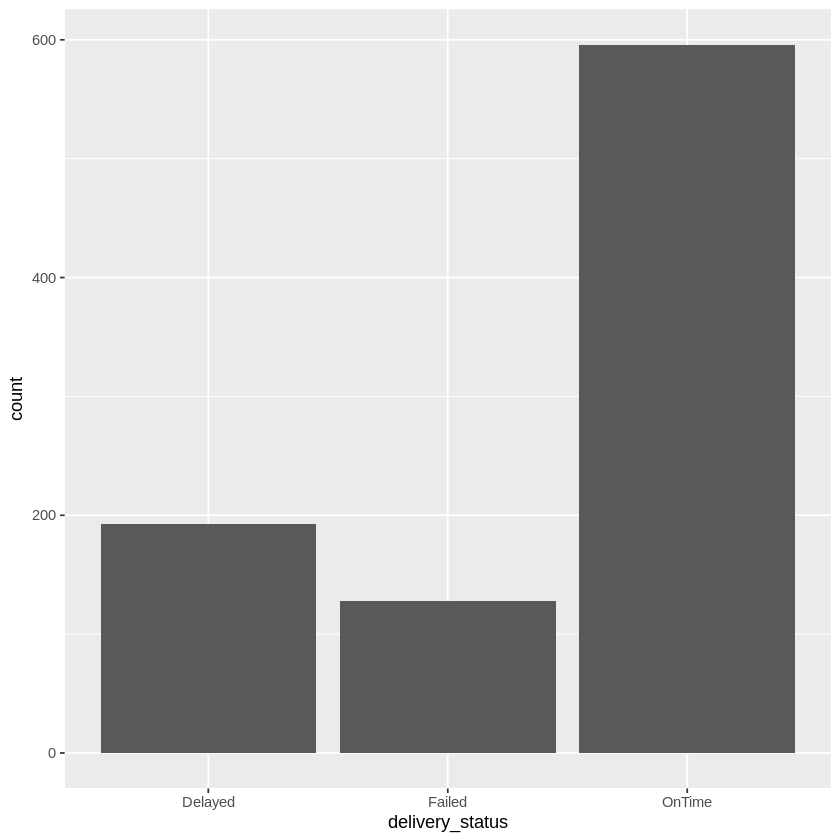

In [ ]:
ggplot(deliveries,
aes(x = delivery_status)) +
geom_bar()

FUEL COST GRAPH

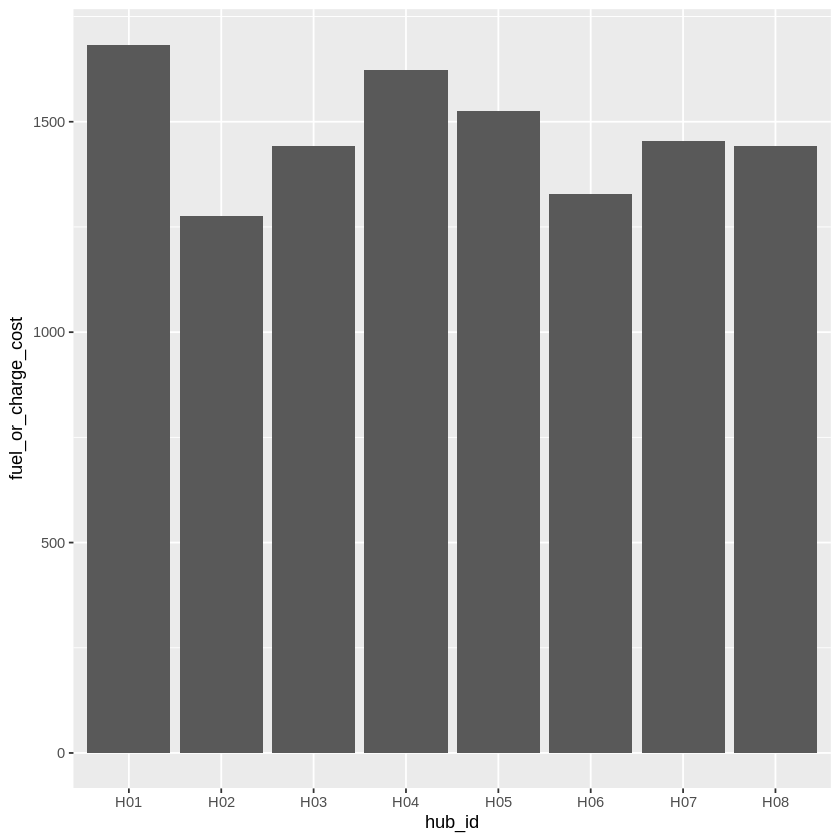

In [ ]:
ggplot(deliveries,
aes(x = hub_id,
y = fuel_or_charge_cost)) +
geom_bar(stat = "identity")

ROUTE DISTANCE HISTOGRAM

`stat_bin()` using `bins = 30`. Pick better value `binwidth`.


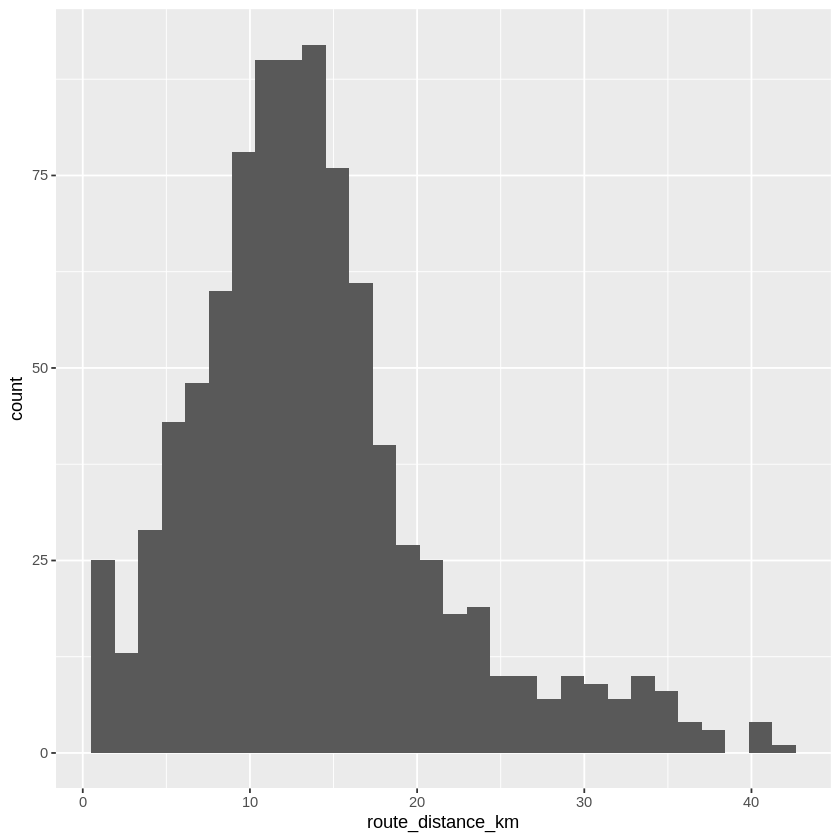

In [ ]:
ggplot(deliveries,
aes(x = route_distance_km)) +
geom_histogram()